In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [4]:

from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

In [14]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

train= pd.read_csv('/content/drive/MyDrive/Fraud_detection/fraudTrain.csv')
test = pd.read_csv('/content/drive/MyDrive/Fraud_detection/fraudTest.csv')

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train Shape: (1296675, 23)
Test Shape: (555719, 23)


In [15]:

print(train.shape)
print(test.shape)
train.head()

(1296675, 23)
(555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [16]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [17]:
print(train.columns)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


In [18]:
train.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [19]:
train=train.dropna()
test=test.dropna()

In [20]:
# remove unnecessary col (non-numerical and useless)
cols_to_drop = [
    'trans_num', 'first', 'last', 'street', 'city',
    'state', 'zip', 'dob', 'job'
]
train.drop(columns=cols_to_drop, inplace=True, errors='ignore')
test.drop(columns=cols_to_drop, inplace=True, errors='ignore')

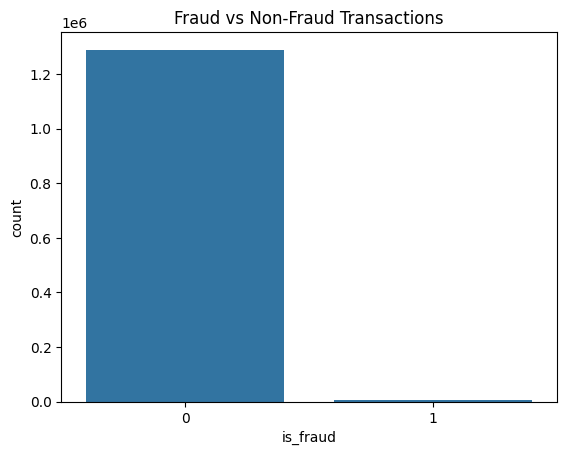

In [21]:
# Fraud vs Non-Fraud Detection

sns.countplot(x='is_fraud',data=train)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

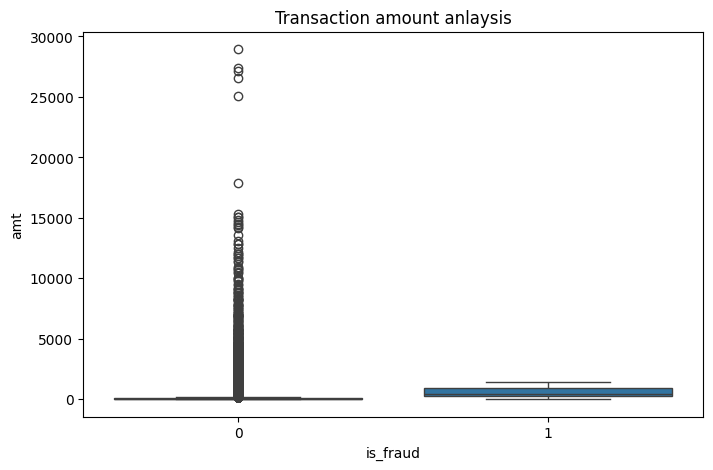

In [22]:
# Transaction amount analysis

plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud',y='amt',data=train)
plt.title("Transaction amount anlaysis")
plt.show()

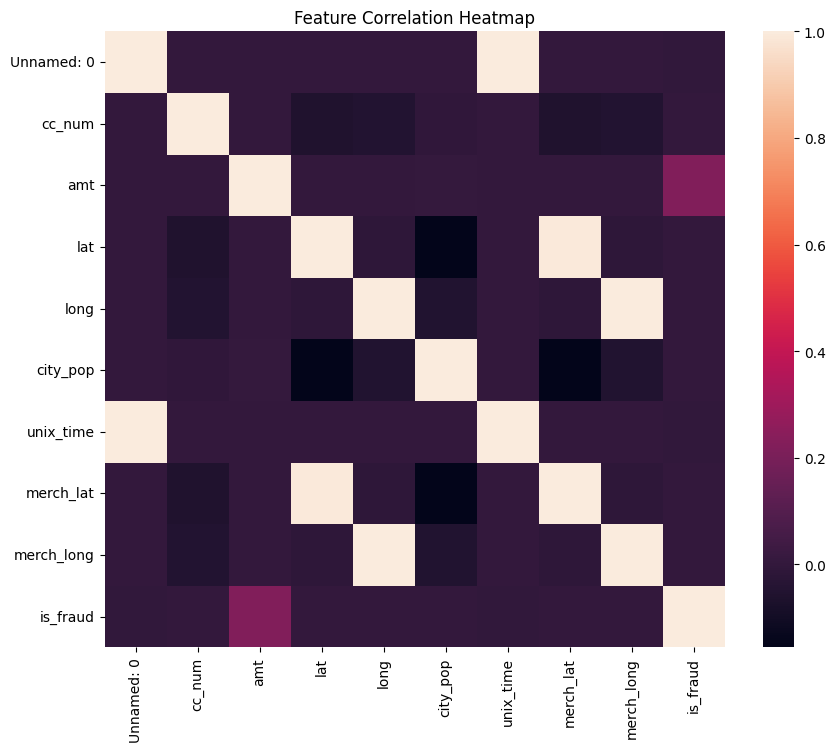

In [23]:
# Correlatioon Heatmap

plt.figure(figsize=(10,8))

num=train.select_dtypes(include=[np.number])
sns.heatmap(num.corr())
#sns.heatmap(train.corr(),cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
print(train.columns)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'gender', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')


In [25]:
#convert datetime col
train['trans_date_trans_time']=pd.to_datetime(train['trans_date_trans_time'])
test['trans_date_trans_time']=pd.to_datetime(test['trans_date_trans_time'])

# extract useful numerical features
train['hour']=train['trans_date_trans_time'].dt.hour
train['day'] = train['trans_date_trans_time'].dt.day
train['month'] = train['trans_date_trans_time'].dt.month

test['hour'] = test['trans_date_trans_time'].dt.hour
test['day'] = test['trans_date_trans_time'].dt.day
test['month'] = test['trans_date_trans_time'].dt.month

# new drop original datetime col
train.drop(columns=['trans_date_trans_time'],inplace=True)
test.drop(columns=['trans_date_trans_time'],inplace=True)

In [26]:
# to convert reamining obj col to numbers (encode catg col)

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in train.select_dtypes(include='object').columns:
    train[col]=le.fit_transform(train[col])
    test[col]=le.transform(test[col])

In [27]:
# define features and target

x_train=train.drop('is_fraud',axis=1)  # axis=1 vertical col to drop col is_fraud
y_train=train['is_fraud']

x_test=test.drop('is_fraud',axis=1)
y_test=test['is_fraud']

print(x_train.shape)
print(y_train.shape) # fun need .shape(), Attribute .shape

(1296675, 15)
(1296675,)


In [28]:
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [29]:
# applying smote
from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("After SMOTE:")
print(pd.Series(y_train_balanced).value_counts())


Before SMOTE:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64
After SMOTE:
is_fraud
0    1289169
1    1289169
Name: count, dtype: int64


In [30]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train_balanced,y_train_balanced)

RandomForestClassifier(random_state=42)

In [31]:
y_pred=model.predict(x_test_scaled)

print(confusion_matrix(y_test,y_pred)) #confusion matrix

[[553408    166]
 [   855   1290]]


In [32]:
print(classification_report(y_test,y_pred)) # classification report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.89      0.60      0.72      2145

    accuracy                           1.00    555719
   macro avg       0.94      0.80      0.86    555719
weighted avg       1.00      1.00      1.00    555719



In [33]:
from sklearn.metrics import roc_auc_score

#ROC_AUC = Reciever Operating Characteristic - Area Under the Curve
roc=roc_auc_score(y_test,y_pred)
print("ROC-AUC Score:", roc) # roc is used to know how well it distinguish b/w 2 classes

ROC-AUC Score: 0.800549365911901
